# Skin Lesion Segmentation (HAM10000) — U-Net + EfficientNet-B0

Improved pipeline:

- ✅ Paired image/mask split (no misalignment)
- ✅ Training-only data augmentation
- ✅ Combined **BCE + Dice** loss for class imbalance
- ✅ LR scheduler + best-checkpoint saving
- ✅ Correct dataset-level metric accumulation

### Colab setup
- Runtime → Change runtime type → **GPU**.
- Configure **Kaggle credentials** so `kagglehub` can download.
- Run top to bottom once.

In [1]:
%pip install -q segmentation_models_pytorch kagglehub scikit-learn albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [2]:
import os
import glob
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
import kagglehub

path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")
print("Path to dataset files:", path)
print("Dataset path exists:", os.path.isdir(path))

100%|██████████| 2.59G/2.59G [00:33<00:00, 83.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2
Dataset path exists: True


## 1️⃣ Dataset

- **Images:** RGB `.jpg`
- **Masks:** segmentation `.png`

Image and mask are augmented **together** so a flip/rotation applied to the image
is applied identically to its mask. Augmentation is enabled only for training.

In [4]:
IMG_SIZE = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SegmentationDataset(Dataset):
    """Loads (image, binary_mask) pairs with optional synchronized augmentation."""

    def __init__(self, image_paths, mask_paths, train=False, img_size=IMG_SIZE):
        assert len(image_paths) == len(mask_paths), "image/mask count mismatch"
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.train = train
        self.img_size = img_size
        self.normalize = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.image_paths)

    def _augment(self, image, mask):
        # Synchronized geometric augmentation (image + mask get the same ops).
        if random.random() < 0.5:
            image = T.functional.hflip(image)
            mask = T.functional.hflip(mask)
        if random.random() < 0.5:
            image = T.functional.vflip(image)
            mask = T.functional.vflip(mask)
        if random.random() < 0.5:
            angle = random.uniform(-20, 20)
            image = T.functional.rotate(image, angle)
            mask = T.functional.rotate(mask, angle)
        # Photometric augmentation applies to the image only.
        if random.random() < 0.5:
            image = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(image)
        return image, mask

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # Resize both (nearest for mask to keep labels crisp).
        image = T.functional.resize(image, [self.img_size, self.img_size])
        mask = T.functional.resize(
            mask, [self.img_size, self.img_size],
            interpolation=T.InterpolationMode.NEAREST,
        )

        if self.train:
            image, mask = self._augment(image, mask)

        # Image -> normalized float tensor.
        image = T.functional.to_tensor(image)
        image = self.normalize(image)

        # Mask -> binary float tensor of shape (1, H, W).
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8))
        mask = (mask != 0).float().unsqueeze(0)

        return image, mask

In [5]:
# 1. Collect and pair paths
root_dir = path
all_images = sorted(glob.glob(f"{root_dir}/images/*.jpg"))
all_masks  = sorted(glob.glob(f"{root_dir}/masks/*.png"))
assert len(all_images) == len(all_masks) and len(all_images) > 0, "Check dataset paths"

# Sanity check: filenames should match between image and mask.
for ip, mp in zip(all_images[:5], all_masks[:5]):
    print(os.path.basename(ip), "<->", os.path.basename(mp))

# 2. Split as PAIRS so an image always stays with its mask
pairs = list(zip(all_images, all_masks))
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)
train_imgs, train_masks = zip(*train_pairs)
test_imgs,  test_masks  = zip(*test_pairs)

# 3. Datasets (augmentation only on train)
train_dataset = SegmentationDataset(list(train_imgs), list(train_masks), train=True)
test_dataset  = SegmentationDataset(list(test_imgs),  list(test_masks),  train=False)

# 4. DataLoaders
BATCH_SIZE = 16  # raise if you have GPU headroom; 128 will OOM on most GPUs
num_workers = 2 if os.name != "nt" else 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")
print(f"DataLoader workers: {num_workers}")

ISIC_0024306.jpg <-> ISIC_0024306_segmentation.png
ISIC_0024307.jpg <-> ISIC_0024307_segmentation.png
ISIC_0024308.jpg <-> ISIC_0024308_segmentation.png
ISIC_0024309.jpg <-> ISIC_0024309_segmentation.png
ISIC_0024310.jpg <-> ISIC_0024310_segmentation.png
Training samples: 8012, Testing samples: 2003
DataLoader workers: 2


### Display a few samples

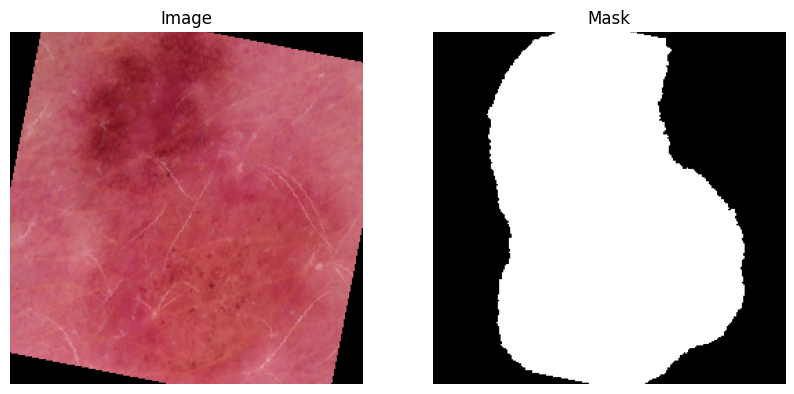

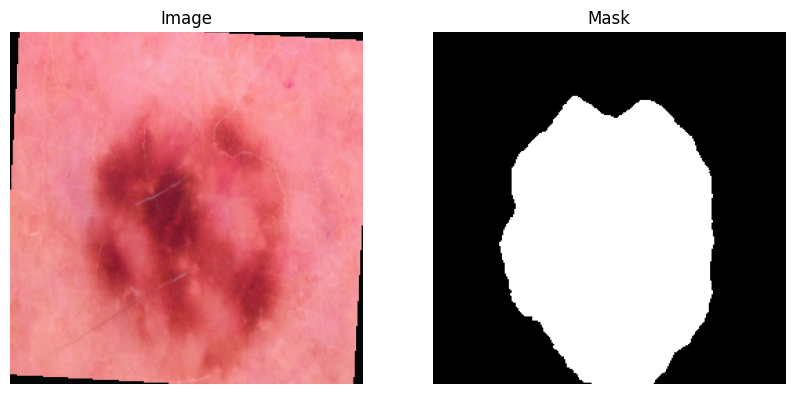

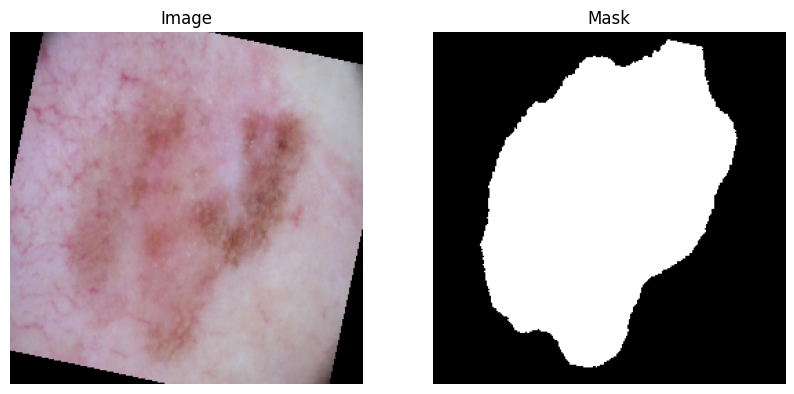

In [6]:
def denormalize(img):
    """Reverse ImageNet normalization for display. img: (C,H,W) tensor."""
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    img = img.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)


for i in range(3):
    img, mask = train_dataset[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(denormalize(img));         axes[0].set_title("Image");  axes[0].axis("off")
    axes[1].imshow(mask.squeeze(), cmap="gray"); axes[1].set_title("Mask"); axes[1].axis("off")
    plt.show()

## 2️⃣ Model

- **U-Net** from `segmentation_models_pytorch`
- Encoder: **pretrained EfficientNet-B0** (ImageNet)
- 1 output channel (binary). We output **logits** and apply sigmoid in the loss/metrics.

In [7]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.2f}M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Trainable parameters: 6.25M


## 3️⃣ Loss & Metrics

**Combined loss = BCEWithLogits + Dice.** BCE alone struggles when lesion pixels are
a small fraction of the image; the Dice term directly optimizes overlap.

Metrics (Dice, IoU, pixel accuracy) are accumulated over the **whole** test set and
computed once at the end, rather than averaging per-batch means.

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(1, 2, 3))
        den = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (num + self.eps) / (den + self.eps)
        return (1 - dice).mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return (self.bce_weight * self.bce(logits, targets)
                + (1 - self.bce_weight) * self.dice(logits, targets))

In [9]:
@torch.no_grad()
def batch_counts(preds, targets):
    """Return summed intersection/union/correct/total counts for a batch.
    Accumulating raw counts (not per-batch ratios) gives correct dataset-level metrics."""
    preds = preds.float()
    targets = targets.float()
    inter = (preds * targets).sum().item()
    pred_sum = preds.sum().item()
    tgt_sum = targets.sum().item()
    correct = (preds == targets).sum().item()
    total = targets.numel()
    return inter, pred_sum, tgt_sum, correct, total


def metrics_from_counts(inter, pred_sum, tgt_sum, correct, total, eps=1e-7):
    dice = (2 * inter + eps) / (pred_sum + tgt_sum + eps)
    union = pred_sum + tgt_sum - inter
    iou = (inter + eps) / (union + eps)
    pix_acc = correct / total
    return dice, iou, pix_acc

## 4️⃣ Train / Validate loops

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, masks in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    agg = np.zeros(5)  # inter, pred_sum, tgt_sum, correct, total
    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        total_loss += criterion(logits, masks).item() * images.size(0)

        preds = (torch.sigmoid(logits) >= 0.5).float()
        agg += np.array(batch_counts(preds, masks))

    val_loss = total_loss / len(loader.dataset)
    dice, iou, pix_acc = metrics_from_counts(*agg)
    return val_loss, dice, iou, pix_acc

## 5️⃣ Run training

- Optimizer: **AdamW**
- Scheduler: **CosineAnnealingLR**
- Saves the **best** checkpoint by validation Dice to `best_model.pth`.

In [11]:
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

NUM_EPOCHS = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, val_losses, val_dices = [], [], []
best_dice = -1.0
BEST_PATH = "best_model.pth"

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_dice, val_iou, val_acc = validate(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), BEST_PATH)
        flag = "  <- saved best"
    else:
        flag = ""

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train {train_loss:.4f} | val {val_loss:.4f} | "
          f"Dice {val_dice:.4f} | IoU {val_iou:.4f} | Acc {val_acc:.4f}{flag}")

print(f"\nBest validation Dice: {best_dice:.4f} (saved to {BEST_PATH})")

train:   0%|          | 0/501 [00:00<?, ?it/s]

Epoch 01/15 | train 0.2598 | val 0.1291 | Dice 0.9357 | IoU 0.8791 | Acc 0.9649  <- saved best


train:   0%|          | 0/501 [00:00<?, ?it/s]

Epoch 02/15 | train 0.1161 | val 0.0894 | Dice 0.9401 | IoU 0.8870 | Acc 0.9671  <- saved best


train:   0%|          | 0/501 [00:00<?, ?it/s]

...

train:   0%|          | 0/501 [00:00<?, ?it/s]

Epoch 14/15 | train 0.0559 | val 0.0681 | Dice 0.9506 | IoU 0.9059 | Acc 0.9732  <- saved best


train:   0%|          | 0/501 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3da163fd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e3da163fd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    ^^self._shutdown_workers()

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

     if w.is_alive():
               ^ ^ ^^^^^^^^^^^^^^^^^^^
^  

Epoch 15/15 | train 0.0560 | val 0.0681 | Dice 0.9506 | IoU 0.9058 | Acc 0.9732

Best validation Dice: 0.9506 (saved to best_model.pth)


### Loss & Dice curves

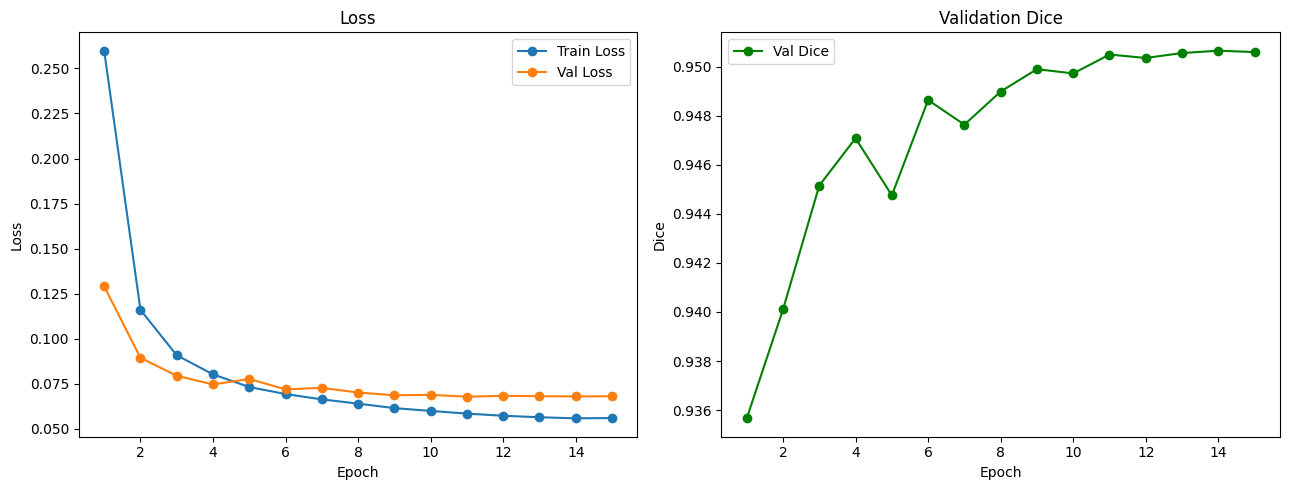

In [12]:
epochs = range(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(epochs, train_losses, marker='o', label='Train Loss')
ax[0].plot(epochs, val_losses, marker='o', label='Val Loss')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].set_title('Loss'); ax[0].legend()

ax[1].plot(epochs, val_dices, marker='o', color='green', label='Val Dice')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Dice')
ax[1].set_title('Validation Dice'); ax[1].legend()

plt.tight_layout(); plt.show()

## 6️⃣ Final evaluation on test set

Loads the best checkpoint and reports dataset-level Dice, IoU, and pixel accuracy.

In [13]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
model.eval()

agg = np.zeros(5)
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="eval"):
        images = images.to(device)
        masks = masks.to(device).float()
        preds = (torch.sigmoid(model(images)) >= 0.5).float()
        agg += np.array(batch_counts(preds, masks))

dice, iou, pix_acc = metrics_from_counts(*agg)
print(f"Test Dice Score:     {dice:.4f}")
print(f"Test IoU Score:      {iou:.4f}")
print(f"Test Pixel Accuracy: {pix_acc:.4f}")

eval:   0%|          | 0/126 [00:00<?, ?it/s]

Test Dice Score:     0.9506
Test IoU Score:      0.9059
Test Pixel Accuracy: 0.9732


## 7️⃣ Visualize predictions

Compare predicted lesion masks against ground truth for a few random test images.

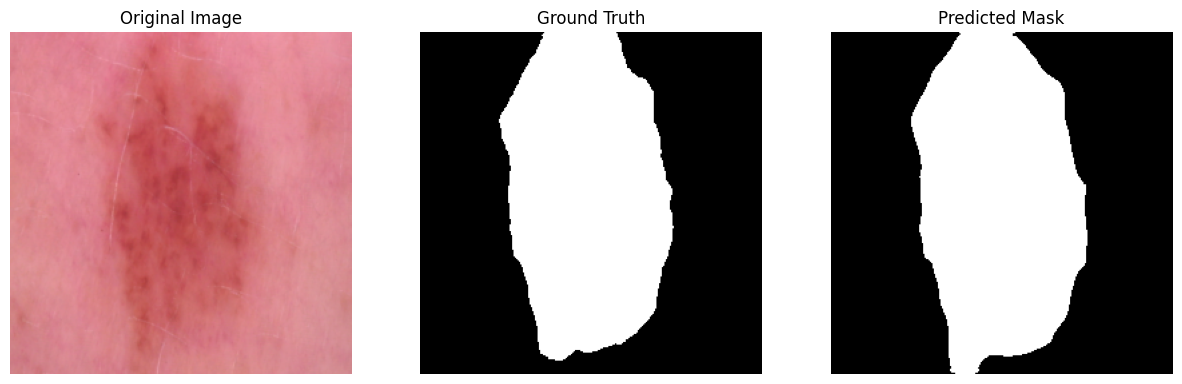

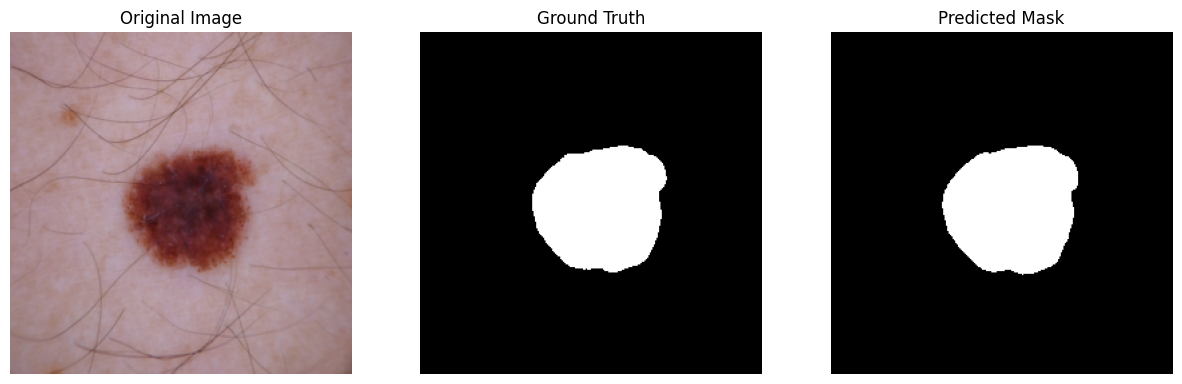

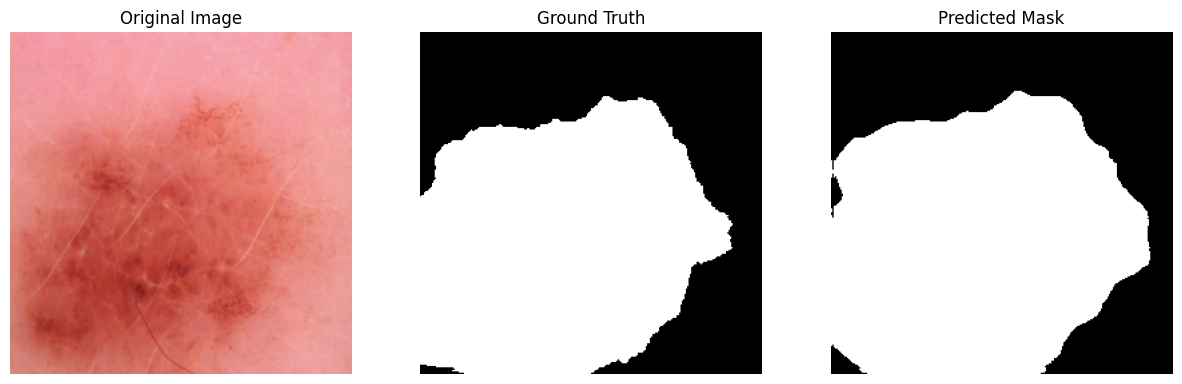

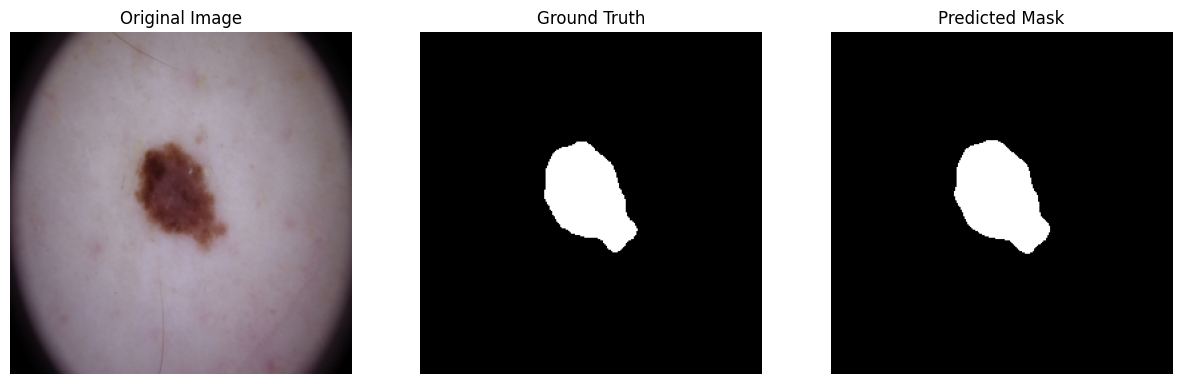

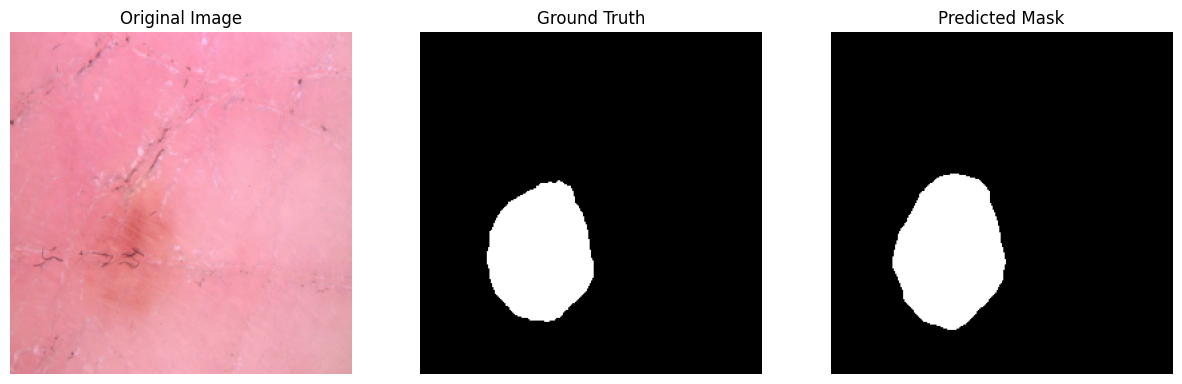

In [14]:
model.eval()
test_samples = random.sample(range(len(test_dataset)), 5)

for idx in test_samples:
    img, mask = test_dataset[idx]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred_mask = (torch.sigmoid(logits) >= 0.5).cpu().squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(denormalize(img));            axes[0].set_title("Original Image");   axes[0].axis("off")
    axes[1].imshow(mask.squeeze(), cmap="gray");  axes[1].set_title("Ground Truth");     axes[1].axis("off")
    axes[2].imshow(pred_mask, cmap="gray");       axes[2].set_title("Predicted Mask");   axes[2].axis("off")
    plt.show()